# Proyecto
## **ING200** - OPTIMIZACIÓN
***Prof**. Jorge Acuña, Ph.D.*

**Integrantes:** *Simón Valdés, Vicente Díaz*

**Fecha:** *Ns*

*Universidad Adolfo Ibáñez*

*Viña del Mar, Chile*

In [30]:
import pandas as pd
from gurobipy import GRB
import gurobipy as gp
import os
import math
import matplotlib.pyplot as plt
import matplotlib.patches as patches


Para procesar el archivo de datos en Excel lo convertimos a dos archivos CSV, uno por cada tabla. Los cargamos como Data Frames a continuación.

In [31]:
operaciones = pd.read_csv("data/Operaciones.csv", sep=";")
permitidas = pd.read_csv("data/Operaciones_Permitidas.csv", sep=",")

In [32]:
# tratar datos de operaciones
#cambiamos coma por punto y pasamos a float
operaciones["Duracion_Horas"] = operaciones["Duracion_Horas"].str.replace(",", ".").astype(float)
#quitamos espacios y pasamos a entero
operaciones["Costo ($)"] = operaciones["Costo ($)"].str.replace(' ', '').astype(int)

operaciones.head()

,ID_Operacion,Duracion_Horas,Tipo,Costo ($)
0,OP001,3.5,Traumatológica,2910051
1,OP002,1.0,Neurológica,3270018
2,OP003,1.5,Gástrica,1840015
3,OP004,1.5,Traumatológica,2080043
4,OP005,3.5,Vascular,3800018


In [33]:
#tratar los datos de permitidas
#hay que convertir en una lista la columna de operaciones permitidas
permitidas['Tipos de operaciones permitidas'] = permitidas['Tipos de operaciones permitidas'].str.split(';')

permitidas.head()

,Pabellón,Tipos de operaciones permitidas
0,Pabellón_1,"[Dérmica, Ginecológica, Otorrinolaringológica,..."
1,Pabellón_2,"[Vascular, Urológica, Gástrica, Neurológica]"
2,Pabellón_3,"[Gástrica, Neurológica, Urológica, Oftalmológi..."
3,Pabellón_4,"[Otorrinolaringológica, Vascular, Ginecológica..."
4,Pabellón_5,"[Gástrica, Traumatológica, Oftalmológica]"


In [34]:
# queremos calcular las operaciones validas
# primero pasar a listas

dias = [1,2,3,4,5]
id_operaciones = operaciones["ID_Operacion"].tolist()
pabellones = permitidas["Pabellón"].tolist()

#hacemos diccionarios para cada operacion
duracion = dict(zip(operaciones["ID_Operacion"], operaciones["Duracion_Horas"]))
costo = dict(zip(operaciones["ID_Operacion"], operaciones["Costo ($)"]))
tipo = dict(zip(operaciones["ID_Operacion"], operaciones["Tipo"]))

#permitidas a diccionario
permitidas_dict = dict(zip(permitidas["Pabellón"], permitidas["Tipos de operaciones permitidas"]))

combinaciones = []
for i in id_operaciones:
    for j in dias:
        for k in pabellones:
            if tipo[i] in permitidas_dict[k]:
                combinaciones.append((i,j,k))

#print(combinaciones)
print(f"operaciones posibles = {len(dias)*len(id_operaciones) * len(pabellones)}")
print(f"operaciones validas = {len(combinaciones)}")

operaciones posibles = 2500
operaciones validas = 1105


In [35]:
# Modelo Base
model = gp.Model("Hospital_Zarcillo")

# Variables de Decisión
# X_i,j,k = 1 si la operacion 'i' se hace el día 'j' en el pabellón 'k', 0 si no.
# i = operacion, j = dia, k = pabellon
X = model.addVars(combinaciones, vtype=GRB.BINARY, name="Asignacion")

# Función Objetivo: Maximizar cantidad total de asignaciones
model.setObjective(X.sum(), GRB.MAXIMIZE)

# Restricciones

# 1) Presupuesto
# La suma de los costos de las operaciones seleccionadas no debe superar 100 millones
model.addConstr(
    gp.quicksum(X[i,j,k] * costo[i] for (i,j,k) in combinaciones) <= 100000000, 
    name="Presupuesto"
)

# 2) Asignación Única
# No repetir operaciones (cada operación se hace máximo 1 vez en toda la semana)
for i in id_operaciones:
    model.addConstr(
        gp.quicksum(X[i,j,k] for (op,j,k) in combinaciones if op == i) <= 1, 
        name=f"No_repeticion_{i}"
    )

# 3) Capacidad de Tiempo Diario
# No pasarse del tiempo permitido diario (10 hrs)
# Suma de (tiempo operacion + 1 hr limpieza) para todas las operaciones en un pabellon en un dia <= 11 hrs
for j in dias:
    for k in pabellones:
        model.addConstr(
            gp.quicksum(X[i,j,k] * (duracion[i] + 1) for (i,dia,pab) in combinaciones if dia == j and pab == k) <= 11,
            name=f"Tiempo_{j}_{k}"
        )

model.update()
print(f"Modelo creado. Variables: {model.NumVars}, Restricciones: {model.NumConstrs}")


Modelo creado. Variables: 1105, Restricciones: 126


**Función Objetivo:**
$$\max Z = \sum_{i \in I} \sum_{j \in J} \sum_{k \in K} X_{i,j,k}$$

**s.a:**

1. **Presupuesto:**
$$\sum_{i \in I} \sum_{j \in J} \sum_{k \in K} X_{i,j,k} \cdot c_i \leq 100.000.000$$

2. **No se repiten las operaciones en otro día o pabellón:**
$$\sum_{j \in J} \sum_{k \in K} X_{i,j,k} \leq 1 \quad \forall i \in I$$

3. **Tiempo Diario Disponible:**
$$\sum_{i \in I} (t_i + 1) \cdot X_{i,j,k} \leq 11 \quad \forall j \in J, \forall k \in K$$

In [36]:
model.optimize()
print("Operaciones máximas a realizar:", model.ObjVal) #pregunta A

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (mac64[arm] - Darwin 25.5.0 25F80)

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 126 rows, 1105 columns and 3315 nonzeros (Max)
Model fingerprint: 0xb0d74440
Model has 1105 linear objective coefficients
Variable types: 0 continuous, 1105 integer (1105 binary)
Coefficient statistics:
  Matrix range     [1e+00, 6e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+08]

Found heuristic solution: objective 39.0000000
Presolve time: 0.01s
Presolved: 126 rows, 1105 columns, 3315 nonzeros
Variable types: 0 continuous, 1105 integer (1105 binary)

Root relaxation: objective 5.886840e+01, 284 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0   58.86840    0   11   39.00

Tenemos que el óptimo son 58 operaciones. Sin embargo, Gurobi devuelve unicamente una solución, por lo que podemos ir optimizando las otras variables en base a un máximo de 58 operaciones, para quizá obtener menor costo o etc.

In [37]:
opt_operaciones = model.ObjVal #=58
# Fijamos las 58 operaciones como restricción
model.addConstr(X.sum() == opt_operaciones, name="Empate_Ops")

# Cambiamos el objetivo para minimizar costo
costo_total = gp.quicksum(X[i,j,k] * costo[i] for (i,j,k) in combinaciones)
model.setObjective(costo_total, GRB.MINIMIZE)
model.optimize()

opt_costo = model.ObjVal
print(f"Óptimo (Min Costo): {opt_costo:,.2f}") #97 millones app

# Fijamos el costo mínimo como restricción para la etapa 3
model.addConstr(costo_total == opt_costo, name="Empate_Costo")

# Cambiamos el objetivo para maximizar la suma de las duraciones
tiempo_uso = gp.quicksum(X[i,j,k] * duracion[i] for (i,j,k) in combinaciones)
model.setObjective(tiempo_uso, GRB.MAXIMIZE)
model.optimize()

opt_tiempo = model.ObjVal
print(f"Óptimo (Max Utilización): {opt_tiempo} horas") #134 hrs

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (mac64[arm] - Darwin 25.5.0 25F80)

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 127 rows, 1105 columns and 4420 nonzeros (Min)
Model fingerprint: 0xdc7e3d03
Model has 1105 linear objective coefficients
Variable types: 0 continuous, 1105 integer (1105 binary)
Coefficient statistics:
  Matrix range     [1e+00, 6e+06]
  Objective range  [9e+05, 6e+06]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+08]

Loaded MIP start from previous solve with objective 9.87229e+07

Presolve time: 0.00s
Presolved: 127 rows, 1105 columns, 4420 nonzeros
Variable types: 0 continuous, 1105 integer (1105 binary)

Root relaxation: objective 9.780291e+07, 242 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

H    0     0           

In [38]:

operaciones_realizadas = [(i, j, k) for (i, j, k) in combinaciones if X[i,j,k].X > 0.5]
print("Pregunta B:")
print("\n1. Cantidad de operaciones")
print(f"Total a realizar: {len(operaciones_realizadas)}")
for d in dias:
    ops_dia = sum(1 for (i, j, k) in operaciones_realizadas if j == d)
    print(f"Día {d}: {ops_dia} operaciones")

print("\n2. Costo asociado")
print(f"Costo Total: ${opt_costo:,.0f}".replace(",", "."))

print("\n3. Porcentaje de cada tipo de operación")
tipos_usados = {}
for (i, j, k) in operaciones_realizadas:
    t = tipo[i]
    tipos_usados[t] = tipos_usados.get(t, 0) + 1

for t, cant in tipos_usados.items():
    porcentaje = (cant / len(operaciones_realizadas)) * 100
    print(f"{t}: {porcentaje:.2f}%")

print("\n4. Porcentaje del dinero usado por tipo")
costo_por_tipo = {}
for (i, j, k) in operaciones_realizadas:
    t = tipo[i]
    costo_por_tipo[t] = costo_por_tipo.get(t, 0) + costo[i]

for t, c in costo_por_tipo.items():
    porcentaje_dinero = (c / opt_costo) * 100
    print(f"{t}: {porcentaje_dinero:.2f}% (${c:,.0f})".replace(",", "."))

print("\n5. Utilización promedio de pabellones")
utilizacion = (opt_tiempo / 250) * 100
print(f"Utilización Promedio: {utilizacion:.2f}%")


Pregunta B:

1. Cantidad de operaciones
Total a realizar: 58
Día 1: 11 operaciones
Día 2: 8 operaciones
Día 3: 12 operaciones
Día 4: 10 operaciones
Día 5: 17 operaciones

2. Costo asociado
Costo Total: $97.802.912

3. Porcentaje de cada tipo de operación
Gástrica: 20.69%
Traumatológica: 13.79%
Ginecológica: 13.79%
Vascular: 3.45%
Dérmica: 12.07%
Urológica: 3.45%
Oftalmológica: 18.97%
Otorrinolaringológica: 13.79%

4. Porcentaje del dinero usado por tipo
Gástrica: 24.07% ($23.540.589)
Traumatológica: 16.51% ($16.150.372)
Ginecológica: 14.27% ($13.960.515)
Vascular: 4.70% ($4.600.068)
Dérmica: 8.39% ($8.210.241)
Urológica: 4.61% ($4.510.138)
Oftalmológica: 14.86% ($14.530.699)
Otorrinolaringológica: 12.58% ($12.300.290)

5. Utilización promedio de pabellones
Utilización Promedio: 53.60%


In [39]:
#graficos
if not os.path.exists("graphs"):
    os.makedirs("graphs")

color_op_fill = '#d0e0ff'
color_op_border = '#003366'
color_limp_fill = '#e6e6e6'
color_limp_border = '#666666'

# Iteramos solo por días. Cada día será 1 imagen.
for d in dias:
    # Ver cuántos pabellones operan este día para darle altura al gráfico
    pabellones_dia = [p for p in pabellones if any(j == d and k == p for (i, j, k) in operaciones_realizadas)]
    if not pabellones_dia:
        continue

    # Crear la figura (la altura crece según cuántos pabellones hay)
    fig, ax = plt.subplots(figsize=(14, 1.5 * len(pabellones_dia)))

    #fondo blanco
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    ax.tick_params(axis='x', colors='black')
    ax.spines['bottom'].set_color('black')

    max_time_global = 20.0

    # Iteramos pabellones. 'reversed' para que el Pabellón 1 quede arriba.
    for y_pos, p in enumerate(reversed(pabellones_dia)):
        ops_pabellon = [(i, duracion[i]) for (i, j, k) in operaciones_realizadas if j == d and k == p]
        start_time = 10.0

        for idx, (op_id, dur) in enumerate(ops_pabellon):
            rect_op = patches.Rectangle((start_time, y_pos - 0.35), dur, 0.7, facecolor=color_op_fill, edgecolor=color_op_border, linewidth=1.5)
            ax.add_patch(rect_op)

            # Textos
            ax.text(start_time + dur/2, y_pos + 0.1, op_id, ha='center', va='center', color=color_op_border, fontweight='bold', fontsize=11)
            ax.text(start_time + dur/2, y_pos - 0.15, f"{dur} h", ha='center', va='center', color=color_op_border, fontsize=10)

            # Línea guía
            ax.vlines(start_time, ymin=y_pos - 0.45, ymax=y_pos - 0.35, color='gray', linestyle='--', linewidth=1)
            start_time += dur

            # limpieza
            if idx < len(ops_pabellon) - 1:
                rect_limp = patches.Rectangle((start_time, y_pos - 0.35), 1, 0.7, facecolor=color_limp_fill, edgecolor=color_limp_border, linewidth=1.5)
                ax.add_patch(rect_limp)

                ax.text(start_time + 0.5, y_pos + 0.1, "Limpieza", ha='center', va='center', color='black', fontsize=9)
                ax.text(start_time + 0.5, y_pos - 0.15, "1 h", ha='center', va='center', color='black', fontsize=9)

                ax.vlines(start_time, ymin=y_pos - 0.45, ymax=y_pos - 0.35, color='gray', linestyle='--', linewidth=1)
                start_time += 1

        # Línea guía
        ax.vlines(start_time, ymin=y_pos - 0.45, ymax=y_pos - 0.35, color='gray', linestyle='--', linewidth=1)
        max_time_global = max(max_time_global, start_time)

    #ejes
    ax.set_xlim(9.5, max_time_global + 0.5)
    ax.set_ylim(-0.5, len(pabellones_dia) - 0.5)

    # Ocultar bordes innecesarios
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    # Ajustar línea inferior (eje X)
    ax.spines['bottom'].set_position(('data', -0.5))
    ax.plot(max_time_global + 0.5, -0.5, ">k", clip_on=False)

    # Ticks X (Horas)
    ticks = [float(x) for x in range(10, int(math.ceil(max_time_global + 0.5)) + 1)]
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{int(x)}:00" for x in ticks])

    # Ticks Y (Nombres de Pabellones en lugar de números)
    ax.set_yticks(range(len(pabellones_dia)))
    ax.set_yticklabels(reversed(pabellones_dia), fontweight='bold', color=color_op_border, fontsize=12)
    ax.tick_params(axis='y', length=0) # Quitar rayita del nombre

    plt.title(f"Cronograma Día {d}", fontweight='bold', color=color_op_border, fontsize=18, pad=20)

    # Guardar 1 archivo por día
    filename = f"graphs/Cronograma_Dia{d}.svg"
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white', transparent=False)
    plt.close()

En la carpeta `graphs/`se habrán creado cronogramas para cada día mostrando las operaciones asignadas a cada pabellón.

## Pregunta C) Maximizar porcentaje de uso de los pabellones

In [40]:
modelo_c = gp.Model("Pregunta C")

X_c = modelo_c.addVars(combinaciones, vtype=GRB.BINARY, name="Asignacion_C")


# Restriccioneo
# 1) Presupuesto
# La suma de los costos de las operaciones seleccionadas no debe superar 100 millones
modelo_c.addConstr(
    gp.quicksum(X_c[i,j,k] * costo[i] for (i,j,k) in combinaciones) <= 100000000,
    name="Presupuesto"
)

# 2) Asignación Única
# No repetir operaciones (cada operación se hace máximo 1 vez en toda la semana)
for i in id_operaciones:
    modelo_c.addConstr(
        gp.quicksum(X_c[i,j,k] for (op,j,k) in combinaciones if op == i) <= 1,
        name=f"No_repeticion_{i}"
    )

# 3) Capacidad de Tiempo Diario
# No pasarse del tiempo permitido diario (10 hrs)
# Suma de (tiempo operacion + 1 hr limpieza) para todas las operaciones en un pabellon en un dia <= 11 hrs
for j in dias:
    for k in pabellones:
        modelo_c.addConstr(
            gp.quicksum(X_c[i,j,k] * (duracion[i] + 1) for (i,dia,pab) in combinaciones if dia == j and pab == k) <= 11,
            name=f"Tiempo_{j}_{k}"
        )

# secuencial: máx tiempo uso
tiempo_uso_c = gp.quicksum(X_c[i,j,k] * duracion[i] for (i,j,k) in combinaciones)
modelo_c.setObjective(tiempo_uso_c, GRB.MAXIMIZE)
modelo_c.optimize()

opt_tiempo_c = modelo_c.objVal
print(f"Óptimo máximo uso: {opt_tiempo_c} hrs")
# asignamos como restriccion
modelo_c.addConstr(tiempo_uso_c == opt_tiempo_c)

#max operaciones
operaciones_c = X_c.sum()
modelo_c.setObjective(operaciones_c, GRB.MAXIMIZE)
modelo_c.optimize()

opt_operaciones_c = modelo_c.objVal
print(f"Óptimo maximo operaciones: {opt_operaciones_c}")
modelo_c.addConstr(operaciones_c == opt_operaciones_c)

# min costo ahora
costo_total_c = gp.quicksum(X_c[i,j,k]*costo[i] for (i,j,k) in combinaciones)
modelo_c.setObjective(costo_total_c, GRB.MINIMIZE)
modelo_c.optimize()

opt_costo_total_c = modelo_c.objVal
print(f"Óptimo Costo mínimo: {opt_costo_total_c:,.2f}")

print(f"Óptimo máximo uso: {opt_tiempo_c} hrs")
print(f"Óptimo maximo operaciones: {opt_operaciones_c}")

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (mac64[arm] - Darwin 25.5.0 25F80)

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 126 rows, 1105 columns and 3315 nonzeros (Max)
Model fingerprint: 0x53947d3d
Model has 1105 linear objective coefficients
Variable types: 0 continuous, 1105 integer (1105 binary)
Coefficient statistics:
  Matrix range     [1e+00, 6e+06]
  Objective range  [1e+00, 4e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+08]

Found heuristic solution: objective 97.5000000
Presolve time: 0.00s
Presolved: 126 rows, 1105 columns, 3315 nonzeros
Variable types: 0 continuous, 1105 integer (1105 binary)

Root relaxation: objective 1.524283e+02, 203 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0  152.42830    0   19   97.50

In [41]:
operaciones_realizadas_c = [(i, j, k) for (i, j, k) in combinaciones if X_c[i,j,k].X > 0.5]

print("Pregunta C")
print("\n1. Cantidad de operaciones")
print(f"Total a realizar: {opt_operaciones_c}")
for d in dias:
    ops_dia_c = sum(1 for (i, j, k) in operaciones_realizadas_c if j == d)
    print(f"Día {d}: {ops_dia_c} operaciones")

print(f"\n2. Costo total: $ {opt_costo_total_c:,.0f}".replace(",", "."))

print("\n3. Utilización promedio de pabellones")
print(f"Utilización Promedio: {(opt_tiempo_c / 250) * 100:.2f}%")

print("\n3. Porcentaje de cada tipo de operación")
tipos_usados = {}
for (i, j, k) in operaciones_realizadas_c:
    t = tipo[i]
    tipos_usados[t] = tipos_usados.get(t, 0) + 1
for t, cant in tipos_usados.items():
    porcentaje = (cant / len(operaciones_realizadas_c)) * 100
    print(f"  {t}: {porcentaje:.2f}%")
print("\n4. Porcentaje del dinero usado por tipo")
costo_por_tipo = {}
for (i, j, k) in operaciones_realizadas_c:
    t = tipo[i]
    costo_por_tipo[t] = costo_por_tipo.get(t, 0) + costo[i]
for t, c in costo_por_tipo.items():
    porcentaje_dinero = (c / opt_costo_total_c) * 100
    print(f"  {t}: {porcentaje_dinero:.2f}% (Gasto: ${c:,.0f})".replace(",", "."))

print("\n5. Utilización promedio de pabellones")
utilizacion = (opt_tiempo_c / 250) * 100
print(f"Utilización Promedio: {utilizacion:.2f}%")




Pregunta C

1. Cantidad de operaciones
Total a realizar: 53.0
Día 1: 10 operaciones
Día 2: 8 operaciones
Día 3: 12 operaciones
Día 4: 11 operaciones
Día 5: 12 operaciones

2. Costo total: $ 99.852.714

3. Utilización promedio de pabellones
Utilización Promedio: 60.80%

3. Porcentaje de cada tipo de operación
  Traumatológica: 22.64%
  Gástrica: 11.32%
  Ginecológica: 11.32%
  Dérmica: 13.21%
  Urológica: 5.66%
  Oftalmológica: 20.75%
  Otorrinolaringológica: 15.09%

4. Porcentaje del dinero usado por tipo
  Traumatológica: 33.30% (Gasto: $33.250.622)
  Gástrica: 12.97% (Gasto: $12.950.361)
  Ginecológica: 11.40% (Gasto: $11.380.327)
  Dérmica: 8.22% (Gasto: $8.210.241)
  Urológica: 7.24% (Gasto: $7.230.174)
  Oftalmológica: 14.55% (Gasto: $14.530.699)
  Otorrinolaringológica: 12.32% (Gasto: $12.300.290)

5. Utilización promedio de pabellones
Utilización Promedio: 60.80%


In [42]:
#graficos c



if not os.path.exists("graphs/Pregunta_C"):
    os.makedirs("graphs/Pregunta_C")

# Generar un gráfico por día
for d in dias:
    pabellones_dia = [p for p in pabellones if any(j == d and k == p for (i, j, k) in operaciones_realizadas_c)]
    if not pabellones_dia: continue

    fig, ax = plt.subplots(figsize=(14, 1.5 * len(pabellones_dia)))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    ax.tick_params(axis='x', colors='black')
    ax.spines['bottom'].set_color('black')

    max_time_global = 20.0
    for y_pos, p in enumerate(reversed(pabellones_dia)):
        ops_pabellon = [(i, duracion[i]) for (i, j, k) in operaciones_realizadas_c if j == d and k == p]
        start_time = 10.0

        for idx, (op_id, dur) in enumerate(ops_pabellon):
            # Operación
            ax.add_patch(patches.Rectangle((start_time, y_pos - 0.35), dur, 0.7, facecolor='#d0e0ff', edgecolor='#003366', linewidth=1.5))
            ax.text(start_time + dur/2, y_pos + 0.1, op_id, ha='center', va='center', color='#003366', fontweight='bold', fontsize=11)
            ax.text(start_time + dur/2, y_pos - 0.15, f"{dur} h", ha='center', va='center', color='#003366', fontsize=10)
            ax.vlines(start_time, ymin=y_pos - 0.45, ymax=y_pos - 0.35, color='gray', linestyle='--', linewidth=1)
            start_time += dur

            # Limpieza
            if idx < len(ops_pabellon) - 1:
                ax.add_patch(patches.Rectangle((start_time, y_pos - 0.35), 1, 0.7, facecolor='#e6e6e6', edgecolor='#666666', linewidth=1.5))
                ax.text(start_time + 0.5, y_pos + 0.1, "Limpieza", ha='center', va='center', color='black', fontsize=9)
                ax.text(start_time + 0.5, y_pos - 0.15, "1 h", ha='center', va='center', color='black', fontsize=9)
                ax.vlines(start_time, ymin=y_pos - 0.45, ymax=y_pos - 0.35, color='gray', linestyle='--', linewidth=1)
                start_time += 1

        ax.vlines(start_time, ymin=y_pos - 0.45, ymax=y_pos - 0.35, color='gray', linestyle='--', linewidth=1)
        max_time_global = max(max_time_global, start_time)

    ax.set_xlim(9.5, max_time_global + 0.5)
    ax.set_ylim(-0.5, len(pabellones_dia) - 0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_position(('data', -0.5))
    ax.plot(max_time_global + 0.5, -0.5, ">k", clip_on=False)

    ticks = [float(x) for x in range(10, int(math.ceil(max_time_global + 0.5)) + 1)]
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{int(x)}:00" for x in ticks])
    ax.set_yticks(range(len(pabellones_dia)))
    ax.set_yticklabels(reversed(pabellones_dia), fontweight='bold', color='#003366', fontsize=12)
    ax.tick_params(axis='y', length=0)

    plt.title(f"Cronograma Completo Día {d} (Modelo C)", fontweight='bold', color='#003366', fontsize=18, pad=20)
    plt.tight_layout()
    plt.savefig(f"graphs/Pregunta_C/Cronograma_Dia{d}.svg", dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()

## Comparación
Comparativa general

|                            | Modelo B   | Modelo C   |
|:---------------------------|------------|------------|
| Total operaciones          | 58         | 53         |
| Utilización de pabellones  | 53,6%      | 60,8%      |
| Costo total ($)            | 97.802.912 | 99.852.714 |

El modelo C logra una mejor utilización de los pabellones, logrando un aumento del 7,2% de utilización. Es más caro, siendo $2.049.802 mayor que el modelo B. Además, logra 5 operaciones menos en total, con 53 versus 58.

Operaciones por día

| Día  | Modelo B | Modelo C |
|:-----|----------|----------|
| 1    | 11       | 10       |
| 2    | 8        | 8        |
| 3    | 12       | 12       |
| 4    | 10       | 11       |
| 5    | 17       | 12       |

El modelo C distribuye de forma más similar las operaciones por cada día.

Tipos de operaciones

| Tipo de Operación         | % (Modelo B) | Costo (Modelo B) | % (Modelo C) | Costo (Modelo C) |
|:--------------------------|--------------|------------------|--------------|------------------|
| **Gástrica**              | 20.69%       | 23.540.589       | 11.32%       | 12.950.361       |
| **Traumatológica**        | 13.79%       | 16.150.372       | 22.64%       | 33.250.622       |
| **Ginecológica**          | 13.79%       | 13.960.515       | 11.32%       | 11.380.327       |
| **Vascular**              | 3.45%        | 4.600.068        | 0.00%        | 0                |
| **Dérmica**               | 12.07%       | 8.210.241        | 13.21%       | 8.210.241        |
| **Urológica**             | 3.45%        | 4.510.138        | 5.66%        | 7.230.174        |
| **Oftalmológica**         | 18.97%       | 14.530.699       | 20.75%       | 14.530.699       |
| **Otorrinolaringológica** | 13.79%       | 12.300.290       | 15.09%       | 12.300.290       |

Acá podemos ver que en el Modelo C no se realiza ninguna operación Vascular, mientras que en el B se hace una. Se hacen más traumatológicas, un 8,85% más. Se hacen menos en gástrica, un 9,37% menos.

Al comparar los cronogramas gráficos, podemos ver que el modelo C toma cirugías más largas, a diferencia del B que intenta poner la mayor cantidad de cirugías por lo que favorece a las de menor tiempo. Como cada cirugía independiente de su tiempo tiene que tener una limpieza de 1 hora, hacer varias operaciones cortas requiere mucho tiempo de limpieza que se "pierde", en cambio, si es una cirugía larga, se requiere 1 sola limpieza.

El modelo C termina atendiendo 5 pacientes menos, sin embargo, toma más operaciones largas, las cuales por su naturaleza son más graves, por lo que estaría priorizando pacientes de gravedad frente a pacientes que requieren operaciones menores.

En conclusión, decidimos que el modelo C es el más apropiado para el contexto del problema, ya que es una situación crítica.
Para agregar y mejorar el modelo, como vimos antes se había anulado la operación vascular al optimizar, por lo que se podría considerar algunos tipos de operación como más prioritarios al asignarle peso al tipo.


## Pregunta D)

In [43]:
# nuevos presupuestos
# 50, 55, ... , 150
presupuestos_nuevos = range(50000000,150000000,5000000) #salta de 5m en 5m


#sensibilidad

resultados_optimos =[]
resultados_costos=[]
for b in presupuestos_nuevos:
    modelo_d = gp.Model(f"Sensibilidad_{b}")
    modelo_d.setParam("OutputFlag", 0) #no imprime nada

    X_d = modelo_d.addVars(combinaciones, vtype=GRB.BINARY, name="X_d")

    #restricciones
    modelo_d.addConstr(gp.quicksum(X_d[i,j,k] * costo[i] for (i,j,k) in combinaciones) <= b, name="Presupuesto")
    for i in id_operaciones:
        modelo_d.addConstr(gp.quicksum(X_d[i,j,k] for (op,j,k) in combinaciones if op == i) <= 1)
    for j in dias:
        for k in pabellones:
            modelo_d.addConstr(
                gp.quicksum(X_d[i,j,k] * (duracion[i] + 1) for (i,dia,pab) in combinaciones if dia == j and pab == k) <= 11
            )
    # 3. Resolución secuencial
    ops_totales = X_d.sum()
    modelo_d.setObjective(ops_totales, GRB.MAXIMIZE)
    modelo_d.optimize()

    if modelo_d.Status == GRB.OPTIMAL:
        opt_ops = modelo_d.ObjVal
        modelo_d.addConstr(ops_totales == opt_ops) # Fijar ops

        costo_total = gp.quicksum(X_d[i,j,k] * costo[i] for (i,j,k) in combinaciones)
        modelo_d.setObjective(costo_total, GRB.MINIMIZE)
        modelo_d.optimize()
        opt_costo = modelo_d.ObjVal

        resultados_optimos.append(opt_ops)
        resultados_costos.append(opt_costo)
    else:
        resultados_optimos.append(0)
        resultados_costos.append(0)


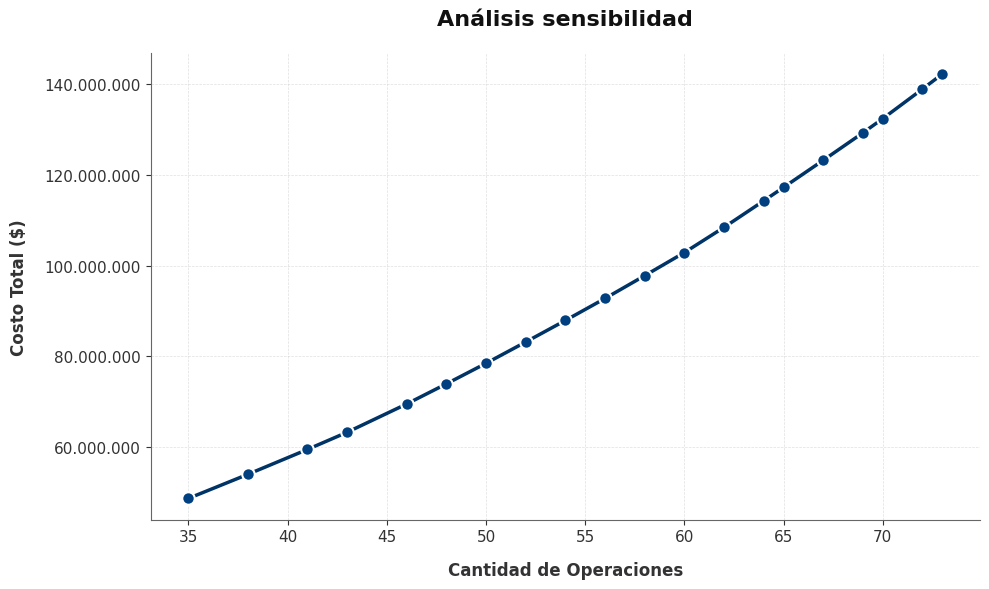

In [44]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.plot(resultados_optimos, resultados_costos, marker='o', linestyle='-',
        color='#003366', linewidth=2.5, markersize=9,
        markerfacecolor='#004080', markeredgecolor='white', markeredgewidth=1.5)

ax.set_xlabel("Cantidad de Operaciones", fontweight='bold', fontsize=12, color='#333333', labelpad=12)
ax.set_ylabel("Costo Total ($)", fontweight='bold', fontsize=12, color='#333333', labelpad=12)
ax.set_title("Análisis sensibilidad",
             fontweight='bold', fontsize=16, color='#111111', pad=20)

# Ajustar los números de los ejes
ax.tick_params(axis='both', colors='#333333', labelsize=11)

# Formatear eje Y para que muestre millones separando con puntos
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)).replace(',','.')))

# 5. Mejorar diseño de grilla y ocultar los bordes superior y derecho
ax.grid(True, linestyle='--', alpha=0.6, color='#cccccc')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#666666')
ax.spines['bottom'].set_color('#666666')

#Ajustar automáticamente los márgenes interiores
plt.tight_layout()

plt.savefig("graphs/Sensibilidad_Presupuesto.svg", dpi=300, facecolor='white', bbox_inches='tight')

plt.show()